In [1]:
import torch
from torch.utils.data import DataLoader , Dataset

In [2]:
import pathlib

img_dir = pathlib.Path(r"C:\Users\Sushant\Pictures\dataset_creation\cat_and_dog") 
file_path = img_dir 
print(file_path)


C:\Users\Sushant\Pictures\dataset_creation\cat_and_dog


In [3]:
file_list = sorted([str(path) for path in img_dir.glob('*.jpg')])

for i in file_list:
    print(i)

C:\Users\Sushant\Pictures\dataset_creation\cat_and_dog\cat_001.jpg
C:\Users\Sushant\Pictures\dataset_creation\cat_and_dog\cat_002.jpg
C:\Users\Sushant\Pictures\dataset_creation\cat_and_dog\cat_003.jpg
C:\Users\Sushant\Pictures\dataset_creation\cat_and_dog\dog.jpg
C:\Users\Sushant\Pictures\dataset_creation\cat_and_dog\dog_1.jpg
C:\Users\Sushant\Pictures\dataset_creation\cat_and_dog\dog_2.jpg


In [4]:
import matplotlib.pyplot as plt
import os 
from PIL import Image

Image Shape (454, 346, 3)
Image Shape (454, 323, 3)
Image Shape (318, 464, 3)
Image Shape (314, 460, 3)
Image Shape (322, 446, 3)
Image Shape (315, 511, 3)


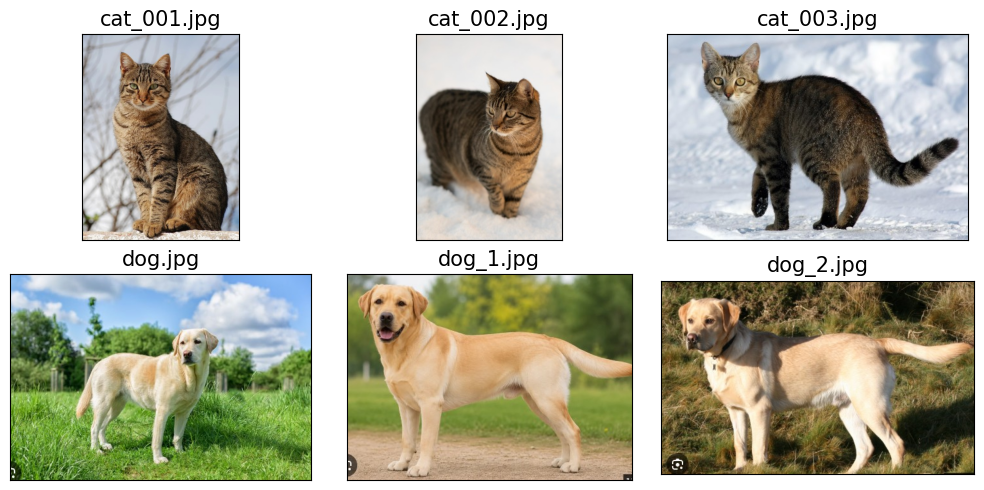

In [5]:
import numpy as np
fig = plt.figure(figsize= (10,5))
for i , file in enumerate(file_list):
    img = Image.open(file)
    print('Image Shape' , np.array(img).shape)
    ax = fig.add_subplot(2,3, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(img)
    ax.set_title(os.path.basename(file) , size = 15)

plt.tight_layout()
plt.show()

In [6]:
print(os.listdir(file_path))
print(file_path)

['cat_001.jpg', 'cat_002.jpg', 'cat_003.jpg', 'dog.jpg', 'dog_1.jpg', 'dog_2.jpg']
C:\Users\Sushant\Pictures\dataset_creation\cat_and_dog


In [7]:
import os 
# changing the file name to label them after
# 2. Define target names and counter
dogs = ["labrador", "labrador_2"]
counter = 1

for f in os.listdir(file_path):
  # 1. Split the filename from its extension (.jpg)
  name_without_ext, ext = os.path.splitext(f)

  # 2. Now check if the name (without extension) matches your list
  if name_without_ext.lower() in dogs:
    old_file = os.path.join(file_path, f)

    # 3. Create the new name
    new_name = f"dog_{counter}{ext}"
    new_file = os.path.join(file_path, new_name)

    # 4. Rename and print
    os.rename(old_file, new_file)
    print(f"Renamed: {f} -> {new_name}")

    counter += 1

In [8]:
print(os.listdir(file_path))

['cat_001.jpg', 'cat_002.jpg', 'cat_003.jpg', 'dog.jpg', 'dog_1.jpg', 'dog_2.jpg']


In [9]:
# # coverting now this into the labels  
# for l in os.listdir(file_path):
#     labels = [1 if 'dog' in os.path.basename(l) else 0] 
#     print(labels)

In [10]:
labels = [1 if 'dog' in os.path.basename(file) else 0 for file in file_list]
print(labels)

[0, 0, 0, 1, 1, 1]


In [11]:
file_lists = os.listdir(file_path)
print(file_lists)
print(labels)

['cat_001.jpg', 'cat_002.jpg', 'cat_003.jpg', 'dog.jpg', 'dog_1.jpg', 'dog_2.jpg']
[0, 0, 0, 1, 1, 1]


In [12]:
# creating the Dataset
class ImageDataset(Dataset):
    
    def __init__(self , x , y):
        self.x = x
        self.y = y
    
    def __getitem__(self , index):
        file = self.x[index]
        label = self.y[index]
        return file , label
    
    def __len__(self):
        return len(labels)
    
    
# creting the dataset
image_dataset = ImageDataset(file_lists , labels)

for f,l in image_dataset:
    print(f,l)

cat_001.jpg 0
cat_002.jpg 0
cat_003.jpg 0
dog.jpg 1
dog_1.jpg 1
dog_2.jpg 1


In [14]:
import torchvision.transforms as transforms

im_ht , im_wd = 80 , 120

transform = transforms.Compose([transforms.ToTensor() , transforms.Resize((im_ht , im_wd)),])  # created a pipeline 

# now creating the dataset again 

class imagedataset(Dataset):
    
    def __init__(self , x, y, transform= None):
        self.x= x
        self.y = y
        self.transform = transform
        
    def __getitem__(self , index):
        img = Image.open(self.x[index])
        if self.transform is not None:
            img = self.transform(img)
            
        label = self.y[index]
        
        return img , label
    
    def __len__(self):
        return len(self.y)
    
image_dataset = imagedataset(file_list , labels , transform)



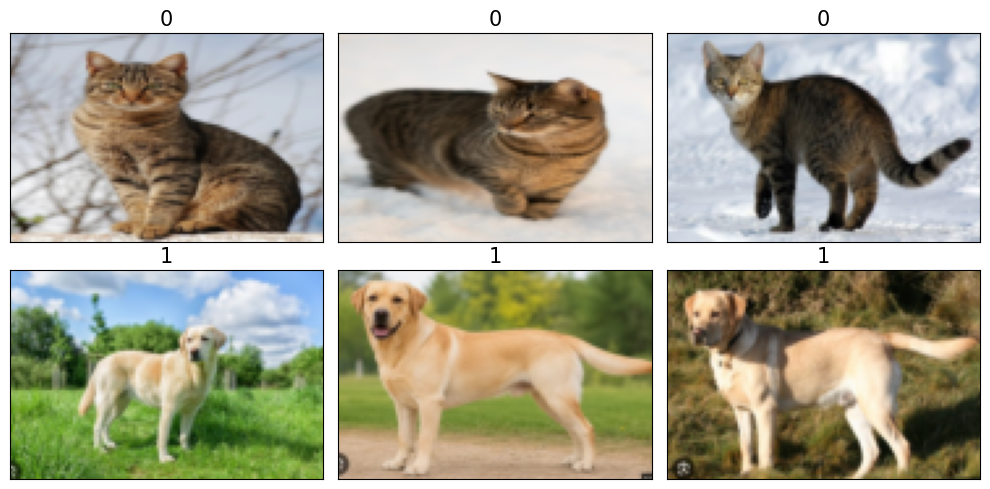

In [15]:
fig = plt.figure(figsize= (10,5))
for i , e in enumerate(image_dataset):
    ax = fig.add_subplot(2,3, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(e[0].numpy().transpose((1,2,0)))
    ax.set_title(f"{e[1]}", size = 15)

plt.tight_layout()
plt.show()

In [19]:
print(image_dataset.__getitem__(2))

(tensor([[[0.7521, 0.7592, 0.7645,  ..., 0.7035, 0.7145, 0.7157],
         [0.7592, 0.7640, 0.7635,  ..., 0.7407, 0.7790, 0.7988],
         [0.7615, 0.7649, 0.7582,  ..., 0.8147, 0.8412, 0.8525],
         ...,
         [0.7918, 0.8100, 0.8190,  ..., 0.8172, 0.8205, 0.8056],
         [0.7873, 0.8054, 0.8135,  ..., 0.7145, 0.7046, 0.6579],
         [0.7945, 0.8044, 0.8104,  ..., 0.6988, 0.6902, 0.6525]],

        [[0.7991, 0.8063, 0.8115,  ..., 0.7547, 0.7681, 0.7689],
         [0.8062, 0.8110, 0.8106,  ..., 0.7816, 0.8124, 0.8279],
         [0.8086, 0.8119, 0.8053,  ..., 0.8443, 0.8632, 0.8702],
         ...,
         [0.8232, 0.8379, 0.8425,  ..., 0.8334, 0.8440, 0.8374],
         [0.8187, 0.8333, 0.8370,  ..., 0.7431, 0.7437, 0.7083],
         [0.8259, 0.8322, 0.8339,  ..., 0.7261, 0.7218, 0.6943]],

        [[0.8540, 0.8612, 0.8665,  ..., 0.8179, 0.8302, 0.8297],
         [0.8611, 0.8659, 0.8655,  ..., 0.8404, 0.8662, 0.8778],
         [0.8635, 0.8668, 0.8602,  ..., 0.8919, 0.9062, 0